## Importando Dados

In [4]:
import pandas as pd


df = pd.read_csv('/content/fraudTrain.csv')


df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [6]:
df["is_fraud"].value_counts(normalize=True)

,proportion
is_fraud,
0,0.994211
1,0.005789


## Feature Engineering e Logistic Regression

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df_model = df.copy()


df_model["trans_date_trans_time"] = pd.to_datetime(df_model["trans_date_trans_time"])

df_model["hour"] = df_model["trans_date_trans_time"].dt.hour
df_model["day"] = df_model["trans_date_trans_time"].dt.day
df_model["month"] = df_model["trans_date_trans_time"].dt.month
df_model["weekday"] = df_model["trans_date_trans_time"].dt.weekday

df_model.drop("trans_date_trans_time", axis=1, inplace=True)


df_model["dob"] = pd.to_datetime(df_model["dob"])

df_model["age"] = (
    pd.Timestamp.today() - df_model["dob"]
).dt.days // 365

df_model.drop("dob", axis=1, inplace=True)


X = df_model.drop("is_fraud", axis=1)
y = df_model["is_fraud"]


num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.41      0.59      0.48      1501

    accuracy                           0.99    259335
   macro avg       0.70      0.79      0.74    259335
weighted avg       0.99      0.99      0.99    259335



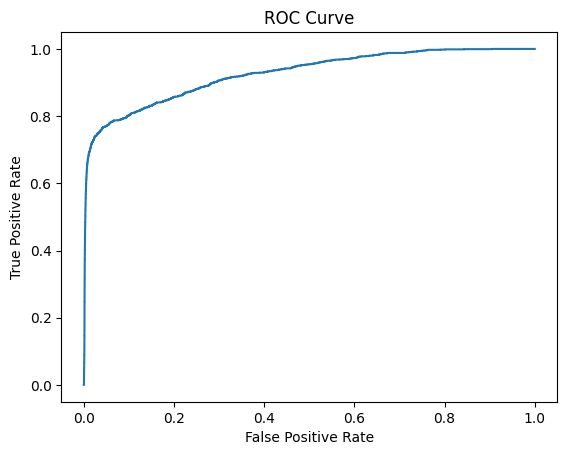

AUC:  0.9253958735215849


In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC: ", roc_auc_score(y_test, y_probs))

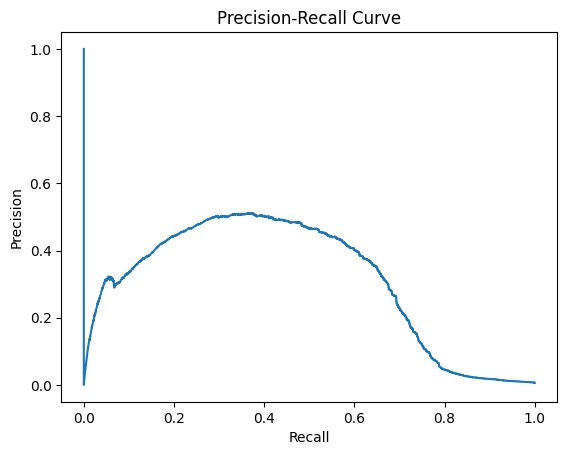

In [31]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## Balanceamento de Dados

In [33]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

X = df_model.drop("is_fraud", axis=1)
y = df_model["is_fraud"]


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include="object").columns


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)


smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_enc, y_train)


print("Antes do SMOTE:")
print(y_train.value_counts())

print("\nDepois do SMOTE:")
print(pd.Series(y_train_bal).value_counts())

Antes do SMOTE:
is_fraud
0    1031335
1       6005
Name: count, dtype: int64

Depois do SMOTE:
is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_bal, y_train_bal)

LogisticRegression(max_iter=1000)

In [35]:
y_pred = model.predict(X_test_enc)

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.44      0.52      0.48      1501

    accuracy                           0.99    259335
   macro avg       0.72      0.76      0.74    259335
weighted avg       0.99      0.99      0.99    259335



## XGBoost


In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)


model.fit(X_train_enc, y_train)


y_pred = model.predict(X_test_enc)


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.97      0.82      0.89      1501

    accuracy                           1.00    259335
   macro avg       0.99      0.91      0.94    259335
weighted avg       1.00      1.00      1.00    259335



## Ajuste de Hiperparâmetros

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_enc, y_train)

best_model = grid.best_estimator_

print("Melhores parâmetros:")
print(grid.best_params_)


y_pred = best_model.predict(X_test_enc)


print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 24 candidates, totalling 72 fits


KeyboardInterrupt: 

## Explicabilidade

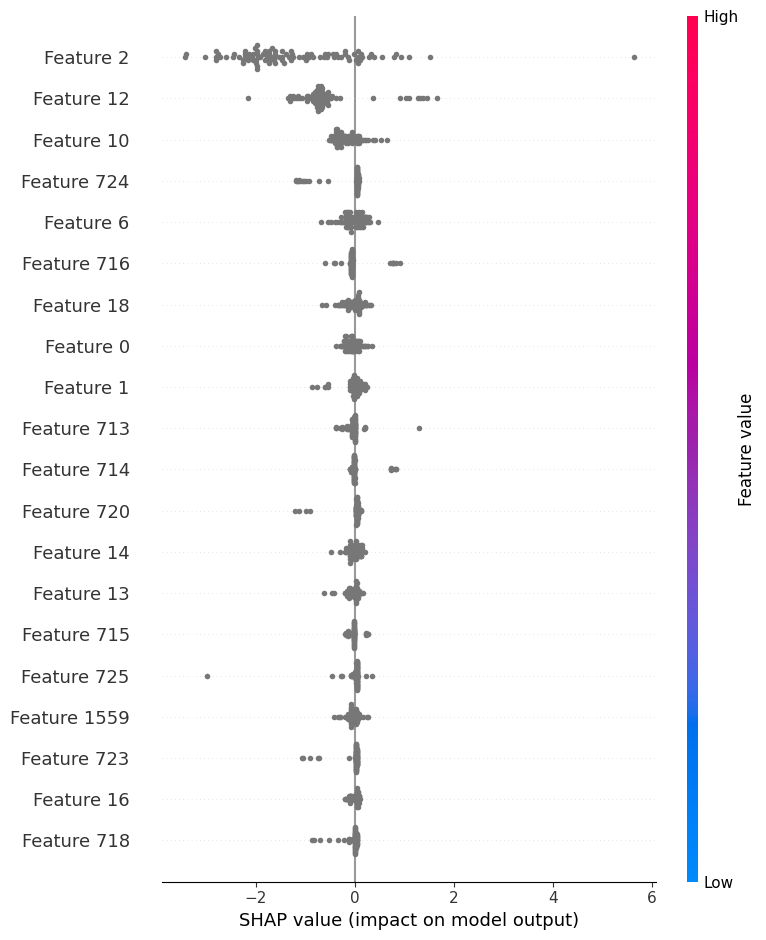

In [43]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_enc[:100])

shap.summary_plot(shap_values, X_test_enc[:100])